## Reto de la semana 3
Diego Andrés Burbano A.

In [128]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive, files

%matplotlib inline

In [129]:
# Montaje del drive
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/datos')

data = pd.read_csv('./BreastCancer.csv', sep=',')

Mounted at /content/drive


In [130]:
data.head()

,radius_mean,smoothness_mean,pronostic
0,0.950308,1.523620,1
1,1.646970,-0.893636,1
2,1.409349,0.891658,1
3,-0.823748,3.254336,1
4,1.571363,0.223788,1


In [131]:
data.shape

(469, 3)

In [132]:
# Definición de candidatos w
w0 = np.array([1, -1, 0.5])
w1 = np.array([0.0603, -1.345, 0.0603])
w2 = np.array([4.0364, 3.597, 1])
w3 = np.array([1.3192, -0.588, 0.502])

# Función para dibujar las rectas
def plot_lines(w):
  x_vals = np.linspace(data['radius_mean'].min(), data['radius_mean'].max(), 400)
  y_vals = -(w[0] * x_vals + w[2]) / w[1]
  plt.plot(x_vals, y_vals, label = f'{w}')
  return


In [133]:
# Definir la función para calcular f(w) usando la función logística
def calcular_f(w, datos):
  # Extraer características y etiquetas
  X = data.iloc[:, :-1].values
  t = data.iloc[:, -1].values
  # Calcular f(w) usando la función logística
  m = len(t)
  f_w = 0
  for i in range(m):
    z_i = np.append(X[i], 1)
    y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
    f_w += t[i] * np.log(y_i) + (1 - t[i]) * np.log(1 - y_i)

  f_w = -f_w / m
  return f_w

# Calcular f(w) para el vector w y los datos de entrenamiento
f_w1 = calcular_f(w1, data)
f_w2 = calcular_f(w2, data)
f_w3 = calcular_f(w3, data)

print(f"El valor de f(w1) es: {f_w1}")
print(f"El valor de f(w2) es: {f_w2}")
print(f"El valor de f(w3) es: {f_w3}")

El valor de f(w1) es: 1.1124209202511601
El valor de f(w2) es: 0.3965874469748862
El valor de f(w3) es: 0.5539213408035415


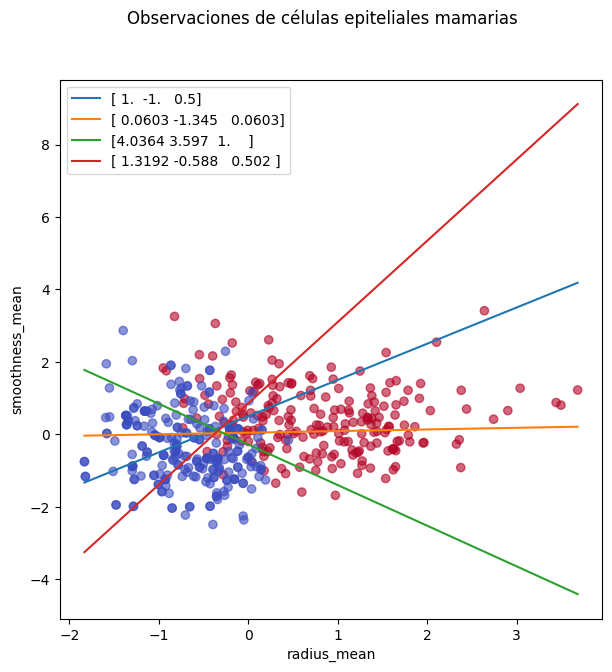

In [134]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.scatter(data['radius_mean'], data['smoothness_mean'], c=data['pronostic'], cmap = 'coolwarm', alpha = 0.6)
plot_lines(w0)
plot_lines(w1)
plot_lines(w2)
plot_lines(w3)

ax.set_xlabel('radius_mean')
ax.set_ylabel('smoothness_mean')
ax.legend()
fig.suptitle('Observaciones de células epiteliales mamarias')
plt.show()


In [135]:
def calcular_gradiente_y_hessiana(w, data):
    # Extraer características y etiquetas
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values

    m = len(t)
    n = len(w)
    grad = np.zeros(n)
    hess = np.zeros((n, n))

    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        y_i = np.clip(y_i, 1e-15, 1 - 1e-15)

        # Gradiente
        grad += (y_i - t[i]) * z_i

        # Hessiana
        hess += y_i * (1 - y_i) * np.outer(z_i, z_i)

    grad = grad / m
    hess = hess / m

    return grad, hess

In [136]:
grad1, hess1 = calcular_gradiente_y_hessiana(w1, data)
grad2, hess2 = calcular_gradiente_y_hessiana(w2, data)
grad3, hess3 = calcular_gradiente_y_hessiana(w3, data)

print("Gradiente w1:\n", grad1)
print("Hessiana w1:\n", hess1)
print("Gradiente w2:\n", grad2)
print("Hessiana w2:\n", hess2)
print("Gradiente w3:\n", grad3)
print("Hessiana w3:\n", hess3)

Gradiente w1:
 [-0.4040456  -0.43232792  0.064808  ]
Hessiana w1:
 [[ 0.18969886  0.02654159  0.0070718 ]
 [ 0.02654159  0.10745162 -0.00268214]
 [ 0.0070718  -0.00268214  0.18637315]]
Gradiente w2:
 [-0.06566774  0.10767964  0.07880696]
Hessiana w2:
 [[ 0.02337852 -0.01420775 -0.01589615]
 [-0.01420775  0.02316092 -0.00079788]
 [-0.01589615 -0.00079788  0.059341  ]]
Gradiente w3:
 [-0.15699393 -0.25618817  0.13398158]
Hessiana w3:
 [[ 0.11605733  0.04361742 -0.04219555]
 [ 0.04361742  0.17727477 -0.0092513 ]
 [-0.04219555 -0.0092513   0.18353103]]


## Analisis y conclusiones

1. Visualmente se puede constatar que el segundo vector o w2 es el que mejor separa los dos conjuntos de datos o de pronóstico, indicando que este candidato es el que presenta un menor error.
2. Verificando el valor de los 3 gradientes calculados, se puede concluye que el menor de ellos corresponde al vector w2, corroborando el análisis visual anterior.
a. w1 y w3 tienen componentes bastante grandes en valor absoluto. Esto significa que la función aún esta inclinada.
b. w2 tiene componentes mas pequeños, especialmente el primer componente (-0.065), indicando que w2 esta mas cerca de un mínimo comparando con w1 y w3.
